In [19]:
'''
Before running the code, ensure you have the necessary libraries installed (numpy, matplotlib, opencv-python,
and scipy). You can install them using pip if you haven't already by running the following command in your terminal:
pip install numpy matplotlib opencv-python scipy
'''

"\nBefore running the code, ensure you have the necessary libraries installed (numpy, matplotlib, opencv-python,\nand scipy). You can install them using pip if you haven't already by running the following command in your terminal:\npip install numpy matplotlib opencv-python scipy\n"

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.signal import convolve2d, correlate2d

In [21]:
def load_image(filepath):
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    return img

In [22]:
def show_image(img, title="Image", cmap='gray'):
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [23]:
# Load the images
dog_img = load_image('dog.jpg')
template_img = load_image('template.jpg')
shelf_img = load_image('shelf.jpg')

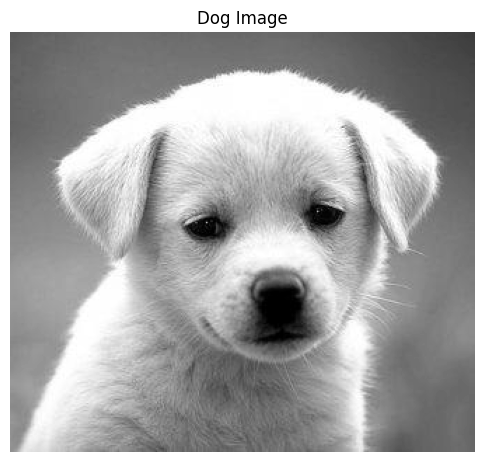

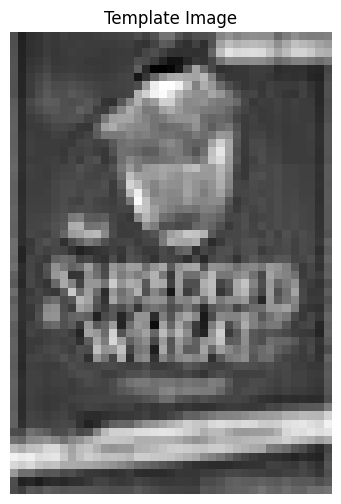

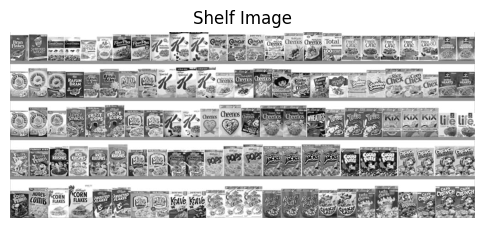

In [24]:
show_image(dog_img, title="Dog Image")
show_image(template_img, title="Template Image")
show_image(shelf_img, title="Shelf Image")

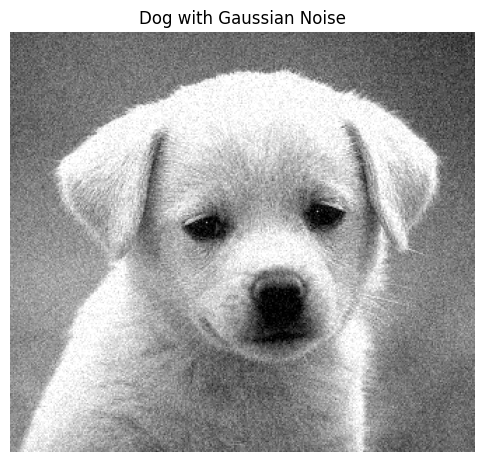

In [25]:
# --- Question 1:

def add_gaussian_noise(image, mean=0, std=15):
    noise = np.random.normal(mean, std, image.shape)
    
    noisy_image = image.astype(np.float32) + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    return noisy_image

noisy_dog = add_gaussian_noise(dog_img)
show_image(noisy_dog, "Dog with Gaussian Noise")

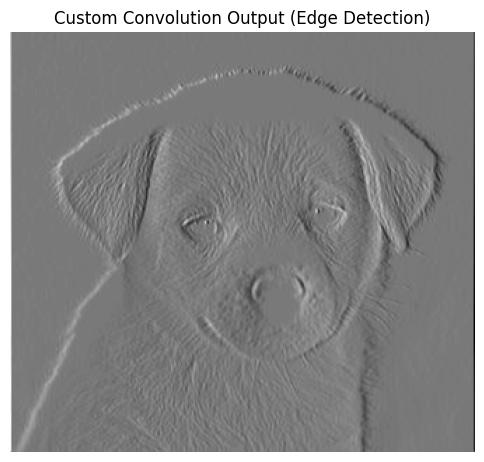

In [26]:
# --- Question 2:

def custom_convolve2d(image, kernel):
    # ii)
    kernel_flipped = np.flip(kernel)
    
    k_h, k_w = kernel_flipped.shape
    img_h, img_w = image.shape
    
    pad_h = k_h // 2
    pad_w = k_w // 2
    
    # i)
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    output = np.zeros_like(image, dtype=np.float32)
    
    # iii)
    for y in range(img_h):
        for x in range(img_w):
            region = padded_image[y:y+k_h, x:x+k_w]
            output[y, x] = np.sum(region * kernel_flipped)
            
    return output

test_kernel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
test_output = custom_convolve2d(dog_img, test_kernel)
show_image(test_output, "Custom Convolution Output (Edge Detection)")

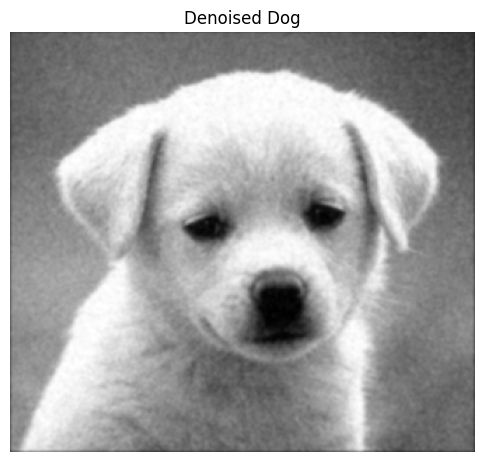

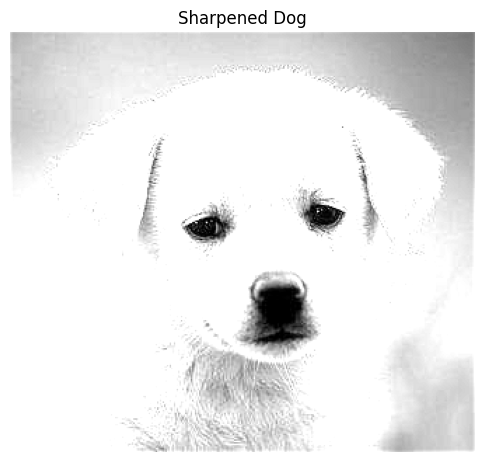

In [27]:
# --- Question 3:

def generate_gaussian_kernel(size, sigma):
    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    g = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return g / g.sum()

gaussian_kernel_7x7 = generate_gaussian_kernel(7, 1.0)

denoised_dog = custom_convolve2d(noisy_dog, gaussian_kernel_7x7)
denoised_dog = np.clip(denoised_dog, 0, 255).astype(np.uint8)

sharpening_kernel = np.array([ 
    [1, 4, 6, 4, 1], 
    [4, 16, 24, 16, 4], 
    [6, 24, -476, 24, 6], 
    [4, 16, 24, 16, 4], 
    [1, 4, 6, 4, 1]
]) * (-1.0/256.0)

sharpened_dog = custom_convolve2d(dog_img, sharpening_kernel)
sharpened_result = np.clip(dog_img.astype(np.float32) + sharpened_dog, 0, 255).astype(np.uint8)

show_image(denoised_dog, "Denoised Dog")
show_image(sharpened_result, "Sharpened Dog")

In [28]:
# --- Question 4:

def template_matching_convolution(image, template):
    template_mean_sub = template.astype(np.float32) - np.mean(template)
    image_float = image.astype(np.float32)
    
    template_flipped = np.flip(template_mean_sub)
    
    result = convolve2d(image_float, template_flipped, mode='valid')
    return result

def template_matching_correlation(image, template):
    template_mean_sub = template.astype(np.float32) - np.mean(template)
    image_float = image.astype(np.float32)
    
    result = correlate2d(image_float, template_mean_sub, mode='valid')
    return result

conv_result = template_matching_convolution(shelf_img, template_img)
corr_result = template_matching_correlation(shelf_img, template_img)

y_conv, x_conv = np.unravel_index(np.argmax(conv_result), conv_result.shape)
y_corr, x_corr = np.unravel_index(np.argmax(corr_result), corr_result.shape)

print(f"Convolution Match Found At: (X: {x_conv}, Y: {y_conv})")
print(f"Correlation Match Found At: (X: {x_corr}, Y: {y_corr})")

'''
e. Both methods accurately locate the product on the shelf. Because convolution mathematically equates to correlation
   when the template is flipped, both produce the exact same highest-intensity peak map if implemented correctly.

f. Correlation is more efficient in terms of computation and implementation. It skips the extra computational step of
   flipping the template (kernel) horizontally and vertically before sliding it across the image.

g. Correlation is better suited for template matching. Template matching fundamentally relies on measuring similarity
   by multiplying overlapping pixels directly. Flipping the image (as convolution requires) is a mathematical
   necessity for signal processing theory (to maintain the commutative property) but serves no practical purpose
   when you just want to overlay a template directly onto an image to check for a visual match.
'''

Convolution Match Found At: (X: 41, Y: 8)
Correlation Match Found At: (X: 41, Y: 8)


'\ne. Both methods accurately locate the product on the shelf. Because convolution mathematically equates to correlation\n   when the template is flipped, both produce the exact same highest-intensity peak map if implemented correctly.\n\nf. Correlation is more efficient in terms of computation and implementation. It skips the extra computational step of\n   flipping the template (kernel) horizontally and vertically before sliding it across the image.\n\ng. Correlation is better suited for template matching. Template matching fundamentally relies on measuring similarity\n   by multiplying overlapping pixels directly. Flipping the image (as convolution requires) is a mathematical\n   necessity for signal processing theory (to maintain the commutative property) but serves no practical purpose\n   when you just want to overlay a template directly onto an image to check for a visual match.\n'